In [5]:
import pandas as pd

df = pd.read_csv("../data/cleaned/reviews_clean.csv")

df.head()

,review,rating,date,bank,source
0,It's not allowing me to transfer money.,2,2026-05-15,CBE,Google Play
1,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play
2,wow,4,2026-05-14,CBE,Google Play
3,nice app,5,2026-05-14,CBE,Google Play
4,formative,5,2026-05-14,CBE,Google Play


In [6]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

c:\Users\Alienware\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Alienware\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Alienware\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Dev

In [7]:
labels = []
scores = []

for text in df["review"]:
    result = sentiment_model(text[:512])[0]  # limit long text

    labels.append(result["label"])
    scores.append(result["score"])

df["sentiment"] = labels
df["sentiment_score"] = scores

In [8]:
df.groupby("bank")["sentiment"].value_counts().unstack()

sentiment,NEGATIVE,POSITIVE
bank,,
BOA,175,133
CBE,120,176
Dashen,133,177


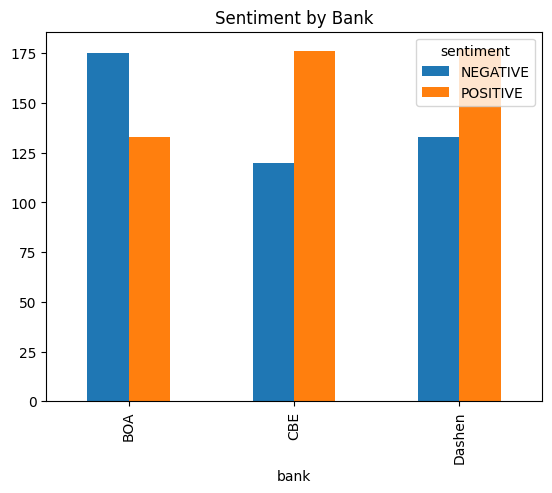

In [9]:
import matplotlib.pyplot as plt

df.groupby("bank")["sentiment"].value_counts().unstack().plot(kind="bar")

plt.title("Sentiment by Bank")
plt.show()

In [18]:
def assign_theme(text):
    text = text.lower()

    if "login" in text or "otp" in text or "password" in text:
        return "Login Issues"

    elif "slow" in text or "loading" in text or "lag" in text:
        return "Performance Issues"

    elif "transfer" in text or "send money" in text:
        return "Transaction Issues"

    elif "ui" in text or "design" in text or "interface" in text:
        return "UI/UX"

    elif "feature" in text or "update" in text:
        return "Feature Requests"

    elif "crash" in text or "freeze" in text:
        return "App Stability"

    else:
        return "Other"

In [21]:
df["theme"] = df["review"].apply(assign_theme)

In [22]:
df.groupby("bank")["theme"].value_counts()

bank    theme             
BOA     Other                 260
        Performance Issues     15
        Feature Requests        8
        Login Issues            7
        Transaction Issues      7
        UI/UX                   7
        App Stability           4
CBE     Other                 252
        Feature Requests       16
        Transaction Issues     15
        App Stability           4
        Performance Issues      4
        UI/UX                   4
        Login Issues            1
Dashen  Other                 247
        UI/UX                  18
        Feature Requests       15
        Performance Issues     14
        Transaction Issues     10
        Login Issues            5
        App Stability           1
Name: count, dtype: int64

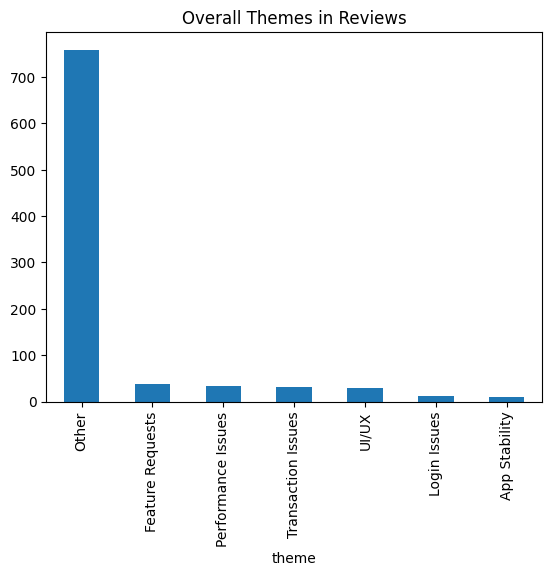

In [23]:
df["theme"].value_counts().plot(kind="bar")

import matplotlib.pyplot as plt
plt.title("Overall Themes in Reviews")
plt.show()

In [27]:
final_df = df[[
    "review",
    "rating",
    "bank",
    "sentiment",
    "sentiment_score",
    "theme"
]]

final_df.to_csv("../data/processed/reviews_with_analysis.csv", index=False)

In [28]:
df.groupby("bank")["sentiment"].value_counts().unstack()

sentiment,NEGATIVE,POSITIVE
bank,,
BOA,175,133
CBE,120,176
Dashen,133,177


In [29]:
df.groupby(["rating", "sentiment"]).size().unstack()

sentiment,NEGATIVE,POSITIVE
rating,,
1,210,22
2,28,4
3,38,15
4,40,30
5,112,415


In [30]:
df.groupby(["bank", "theme"]).size()

bank    theme             
BOA     App Stability           4
        Feature Requests        8
        Login Issues            7
        Other                 260
        Performance Issues     15
        Transaction Issues      7
        UI/UX                   7
CBE     App Stability           4
        Feature Requests       16
        Login Issues            1
        Other                 252
        Performance Issues      4
        Transaction Issues     15
        UI/UX                   4
Dashen  App Stability           1
        Feature Requests       15
        Login Issues            5
        Other                 247
        Performance Issues     14
        Transaction Issues     10
        UI/UX                  18
dtype: int64